# 64 - Speckle-Adaptive R Combined Candidate Sweep

Focused follow-up to Notebook 63. Instead of changing one knob at a time, this notebook tests a small set of named combined recipes for the speckle-confidence-to-adaptive-`R` rule.

The goal is to find practical rule-of-thumb candidates, not an exhaustive optimum. Each candidate is run on the same first-30-second window and compared on:

- confidence timing and low-confidence tail
- `R_scale` timing and aggressiveness
- fixed-vs-adaptive UltraTimTrack output deltas
- runtime-relevant sampling choices such as search radius and block size


## 1. Imports and Setup

In [1]:
from __future__ import annotations

import csv
import hashlib
import json
import sys
from dataclasses import asdict, replace
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.speckle_confidence import SpeckleConfidenceConfig, confidence_to_r_scale
from ultrasound_tracker.ultratimtrack_matlab_2state import (
    MatlabTwoStateKalmanConfig,
    run_matlab_2state_kalman,
)
from ultrasound_tracker.ultratrack_klt import read_gray_frames

VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
ROI_PATH = ROOT / 'data' / 'rois' / 'UltraTimTrack_test_rois.json'
STRICT_BASELINE = ROOT / 'results' / 'strict_ultratimtrack_runs' / 'UltraTimTrack_test' / 'UltraTimTrack_test_strict_results.npz'
UTT_EXPORT = Path('/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat')
OUT = ROOT / 'results' / 'notebook64_speckle_adaptive_R_combined_candidates'
CACHE = OUT / 'confidence_cache'
OUT.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

# Combined-candidate scout window. Set to None for the full sequence after narrowing candidates.
MAX_SECONDS = 30.0
FORCE_RECOMPUTE = False
VALID_FRACTION_FLOOR = 0.25

BASE_CONFIG = SpeckleConfidenceConfig(
    block_size=21,
    stride=24,
    search_radius=8,
    zncc_low=0.45,
    zncc_high=0.90,
    confidence_floor=0.05,
    r_min_scale=0.5,
    r_max_scale=20.0,
    r_gamma=1.5,
    motion_spread_scale_px=3.0,
    forward_backward_scale_px=2.0,
)

for path in [VIDEO, ROI_PATH, STRICT_BASELINE, UTT_EXPORT]:
    print(path, 'OK' if path.exists() else 'MISSING')
print('output:', OUT)

/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 OK
/Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json OK
/Users/grosbedou/PycharmProjects/NDORMS/results/strict_ultratimtrack_runs/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz OK
/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat OK
output: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook64_speckle_adaptive_R_combined_candidates


## 2. Load Baseline Inputs

In [2]:
def video_info(path: Path) -> tuple[float, int, int, int]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ok, frame0 = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f'Could not read first frame from {path}')
    return fps, n_frames, int(frame0.shape[0]), int(frame0.shape[1])


with ROI_PATH.open('r', encoding='utf-8') as f:
    rois = json.load(f)
fascicle_roi = tuple(int(v) for v in rois['fascicle'])

fps, video_n_frames, image_h, image_w = video_info(VIDEO)
baseline = np.load(STRICT_BASELINE, allow_pickle=True)
n_all = min(len(baseline['frame']), video_n_frames)
if MAX_SECONDS is None:
    n_conf = n_all
else:
    n_conf = min(n_all, int(round(float(MAX_SECONDS) * fps)))

time_all = np.asarray(baseline['time_s'][:n_all], dtype=float)
time_conf = time_all[:n_conf]
super_lines = np.asarray(baseline['sup_apo_lines'][:n_all], dtype=float)
deep_lines = np.asarray(baseline['deep_apo_lines'][:n_all], dtype=float)
frames = read_gray_frames(VIDEO, limit=n_conf)

print({
    'fps': fps,
    'video_frames': video_n_frames,
    'image_shape': (image_h, image_w),
    'n_all': n_all,
    'n_conf': n_conf,
    'seconds': float(time_conf[-1]) if n_conf else 0.0,
    'fascicle_roi': fascicle_roi,
})

{'fps': 33.341, 'video_frames': 2667, 'image_shape': (562, 706), 'n_all': 2667, 'n_conf': 1000, 'seconds': 29.963108485048437, 'fascicle_roi': (23, 78, 679, 218)}


## 3. Speckle Confidence Helpers

This repeats the Notebook 62 forward-backward confidence rule, but strips out strain and local-array storage so sweeps stay lighter.

In [3]:
def line_y_at_x(line: np.ndarray, x: np.ndarray) -> np.ndarray:
    line = np.asarray(line, dtype=float).reshape(4)
    x1, y1, x2, y2 = line
    if abs(x2 - x1) < 1e-9:
        return np.full_like(x, np.nan, dtype=float)
    return y1 + (y2 - y1) * (x - x1) / (x2 - x1)


def sample_roi_grid(roi_box, config: SpeckleConfidenceConfig, extra_border=4):
    x, y, w, h = [int(v) for v in roi_box]
    border = int(config.block_size // 2 + config.search_radius + extra_border)
    xs = np.arange(x + border, x + w - border + 1, int(config.stride), dtype=float)
    ys = np.arange(y + border, y + h - border + 1, int(config.stride), dtype=float)
    if len(xs) == 0 or len(ys) == 0:
        return np.empty((0, 2), dtype=np.float32)
    xx, yy = np.meshgrid(xs, ys)
    return np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)


def muscle_band_mask(points, super_line, deep_line, margin=3.0):
    points = np.asarray(points, dtype=float).reshape(-1, 2)
    y_super = line_y_at_x(super_line, points[:, 0])
    y_deep = line_y_at_x(deep_line, points[:, 0])
    upper = np.minimum(y_super, y_deep) + margin
    lower = np.maximum(y_super, y_deep) - margin
    return np.isfinite(upper) & np.isfinite(lower) & (points[:, 1] >= upper) & (points[:, 1] <= lower)


def robust_mad(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan
    med = np.median(values)
    return float(1.4826 * np.median(np.abs(values - med)))


def clip_confidence(values, config: SpeckleConfidenceConfig):
    return np.clip(values, float(config.confidence_floor), float(config.confidence_ceiling))


def match_patch_at(source, target, point, config: SpeckleConfidenceConfig):
    source = np.asarray(source, dtype=np.float32)
    target = np.asarray(target, dtype=np.float32)
    h, w = source.shape[:2]
    pr = int(config.block_size) // 2
    sr = int(config.search_radius)
    x, y = np.rint(np.asarray(point, dtype=np.float32)).astype(int)

    if x - pr < 0 or x + pr + 1 > w or y - pr < 0 or y + pr + 1 > h:
        return None
    if x - pr - sr < 0 or x + pr + sr + 1 > target.shape[1] or y - pr - sr < 0 or y + pr + sr + 1 > target.shape[0]:
        return None

    patch = source[y - pr : y + pr + 1, x - pr : x + pr + 1]
    if float(np.var(patch)) < float(config.min_texture_variance):
        return None

    sx0 = x - pr - sr
    sy0 = y - pr - sr
    search = target[sy0 : y + pr + sr + 1, sx0 : x + pr + sr + 1]
    response = cv2.matchTemplate(search, patch, cv2.TM_CCOEFF_NORMED)
    _, score, _, best_loc = cv2.minMaxLoc(response)
    matched = np.asarray([sx0 + best_loc[0] + pr, sy0 + best_loc[1] + pr], dtype=np.float32)
    return matched, float(score)


def block_match_forward_backward(prev_frame, curr_frame, points, config: SpeckleConfidenceConfig):
    points = np.asarray(points, dtype=np.float32).reshape(-1, 2)
    n = len(points)
    displacements = np.full((n, 2), np.nan, dtype=np.float32)
    zncc_scores = np.full(n, np.nan, dtype=np.float32)
    fb_errors = np.full(n, np.nan, dtype=np.float32)
    valid_mask = np.zeros(n, dtype=bool)

    for idx, point in enumerate(points):
        forward = match_patch_at(prev_frame, curr_frame, point, config)
        if forward is None:
            continue
        curr_point, score = forward
        if not np.isfinite(score):
            continue
        reverse = match_patch_at(curr_frame, prev_frame, curr_point, config)
        if reverse is not None:
            back_point, _ = reverse
            fb_errors[idx] = float(np.linalg.norm(back_point - point))
        displacements[idx] = curr_point - point
        zncc_scores[idx] = score
        valid_mask[idx] = True

    return displacements, zncc_scores, fb_errors, valid_mask


def local_confidence_from_matches(displacements, zncc_scores, fb_errors, valid_mask, config: SpeckleConfidenceConfig):
    displacements = np.asarray(displacements, dtype=float)
    zncc_scores = np.asarray(zncc_scores, dtype=float)
    fb_errors = np.asarray(fb_errors, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool) & np.isfinite(zncc_scores) & np.all(np.isfinite(displacements), axis=1)

    speckle_conf = np.zeros(len(zncc_scores), dtype=float)
    motion_conf = np.zeros(len(zncc_scores), dtype=float)
    fb_conf = np.zeros(len(zncc_scores), dtype=float)
    local_conf_no_fb = np.zeros(len(zncc_scores), dtype=float)
    local_conf = np.zeros(len(zncc_scores), dtype=float)

    if not np.any(valid_mask):
        return local_conf, local_conf_no_fb, fb_conf, np.full(2, np.nan), np.nan, np.nan

    speckle_raw = (zncc_scores[valid_mask] - float(config.zncc_low)) / max(float(config.zncc_high - config.zncc_low), 1e-12)
    speckle_conf[valid_mask] = clip_confidence(np.clip(speckle_raw, 0.0, 1.0), config)

    d_med = np.nanmedian(displacements[valid_mask], axis=0)
    residuals = np.linalg.norm(displacements - d_med, axis=1)
    motion_conf[valid_mask] = clip_confidence(
        np.exp(-residuals[valid_mask] / max(float(config.motion_spread_scale_px), 1e-12)),
        config,
    )

    fb_conf[valid_mask] = float(config.confidence_floor)
    finite_fb = valid_mask & np.isfinite(fb_errors)
    fb_conf[finite_fb] = clip_confidence(
        np.exp(-fb_errors[finite_fb] / max(float(config.forward_backward_scale_px), 1e-12)),
        config,
    )

    no_fb = speckle_conf[valid_mask] * motion_conf[valid_mask]
    with_fb = no_fb * fb_conf[valid_mask]
    local_conf_no_fb[valid_mask] = clip_confidence(no_fb, config)
    local_conf[valid_mask] = clip_confidence(with_fb, config)
    median_fb_error = float(np.nanmedian(fb_errors[finite_fb])) if np.any(finite_fb) else np.nan
    return local_conf, local_conf_no_fb, fb_conf, d_med, robust_mad(residuals[valid_mask]), median_fb_error


def adaptive_r_scale(confidence, config: SpeckleConfidenceConfig):
    confidence = np.asarray(confidence, dtype=float)
    return np.asarray([confidence_to_r_scale(float(c), config) for c in confidence], dtype=np.float64)

## 4. Combined Candidate Definitions

The recipes below combine the most useful directions from Notebook 63:

- keep `block_size=21`, `stride=24` as the main working point
- test `search_radius=4` as a cheaper option
- test stricter confidence through `zncc_high`, forward-backward penalty, and motion spread
- test whether the `R` mapping should be more aggressive once confidence drops
- keep one larger-block recipe as a smoother comparison


In [4]:
def make_candidate_configs(base: SpeckleConfidenceConfig):
    return [
        (
            'base_21_24_r8',
            'baseline',
            base,
            'current Notebook 62/63 rule-of-thumb',
        ),
        (
            'efficient_r4',
            'efficient',
            replace(base, search_radius=4),
            'same confidence rule, smaller search radius for speed and fewer false searches',
        ),
        (
            'strict_conf_r4',
            'strict_confidence',
            replace(
                base,
                search_radius=4,
                zncc_high=0.95,
                forward_backward_scale_px=1.0,
                motion_spread_scale_px=2.0,
            ),
            'stricter ZNCC, forward-backward, and motion-coherence penalties',
        ),
        (
            'aggressive_R_map',
            'R_mapping',
            replace(base, r_gamma=1.0, r_max_scale=30.0),
            'same confidence as base, but stronger R response when confidence falls',
        ),
        (
            'strict_conf_aggressive_R',
            'strict_plus_R',
            replace(
                base,
                search_radius=4,
                zncc_high=0.95,
                forward_backward_scale_px=1.0,
                motion_spread_scale_px=2.0,
                r_gamma=1.0,
                r_max_scale=30.0,
            ),
            'strict confidence plus stronger R mapping',
        ),
        (
            'smooth_block31_r4',
            'smoother_block',
            replace(base, block_size=31, search_radius=4),
            'larger block with cheaper search; checks whether smoothing over-trusts speckle',
        ),
    ]


SWEEP_SPECS = make_candidate_configs(BASE_CONFIG)
print(f'{len(SWEEP_SPECS)} combined candidates')
for name, group, cfg, note in SWEEP_SPECS:
    print(
        f'{name:26s} {group:18s} '
        f'block={cfg.block_size:2d} stride={cfg.stride:2d} search={cfg.search_radius:2d} '
        f'zncc=[{cfg.zncc_low:.2f},{cfg.zncc_high:.2f}] fb={cfg.forward_backward_scale_px:.1f} '
        f'motion={cfg.motion_spread_scale_px:.1f} R=[{cfg.r_min_scale:.1f},{cfg.r_max_scale:.1f}] gamma={cfg.r_gamma:.1f} | {note}'
    )

6 combined candidates
base_21_24_r8              baseline           block=21 stride=24 search= 8 zncc=[0.45,0.90] fb=2.0 motion=3.0 R=[0.5,20.0] gamma=1.5 | current Notebook 62/63 rule-of-thumb
efficient_r4               efficient          block=21 stride=24 search= 4 zncc=[0.45,0.90] fb=2.0 motion=3.0 R=[0.5,20.0] gamma=1.5 | same confidence rule, smaller search radius for speed and fewer false searches
strict_conf_r4             strict_confidence  block=21 stride=24 search= 4 zncc=[0.45,0.95] fb=1.0 motion=2.0 R=[0.5,20.0] gamma=1.5 | stricter ZNCC, forward-backward, and motion-coherence penalties
aggressive_R_map           R_mapping          block=21 stride=24 search= 8 zncc=[0.45,0.90] fb=2.0 motion=3.0 R=[0.5,30.0] gamma=1.0 | same confidence as base, but stronger R response when confidence falls
strict_conf_aggressive_R   strict_plus_R      block=21 stride=24 search= 4 zncc=[0.45,0.95] fb=1.0 motion=2.0 R=[0.5,30.0] gamma=1.0 | strict confidence plus stronger R mapping
smooth_blo

## 5. Run Combined Candidate Confidence Series

In [5]:
def config_payload(config: SpeckleConfidenceConfig):
    payload = asdict(config)
    # Keep hashes stable and small for the parameters this notebook varies.
    return {
        'block_size': payload['block_size'],
        'stride': payload['stride'],
        'search_radius': payload['search_radius'],
        'min_texture_variance': payload['min_texture_variance'],
        'zncc_low': payload['zncc_low'],
        'zncc_high': payload['zncc_high'],
        'confidence_floor': payload['confidence_floor'],
        'confidence_ceiling': payload['confidence_ceiling'],
        'r_min_scale': payload['r_min_scale'],
        'r_max_scale': payload['r_max_scale'],
        'r_gamma': payload['r_gamma'],
        'motion_spread_scale_px': payload['motion_spread_scale_px'],
        'forward_backward_scale_px': payload['forward_backward_scale_px'],
    }


def cache_path(name: str, config: SpeckleConfidenceConfig):
    encoded = json.dumps(config_payload(config), sort_keys=True).encode('utf-8')
    digest = hashlib.md5(encoded).hexdigest()[:10]
    return CACHE / f'{name}_{digest}_first_{n_conf}_frames.npz'


def run_confidence_series(name: str, config: SpeckleConfidenceConfig):
    path = cache_path(name, config)
    if path.exists() and not FORCE_RECOMPUTE:
        data = dict(np.load(path, allow_pickle=True))
        data['cache_path'] = str(path)
        data['loaded_cache'] = True
        return data

    base_points = sample_roi_grid(fascicle_roi, config)
    n_points = len(base_points)
    global_conf = np.ones(n_conf, dtype=np.float32)
    global_conf_no_fb = np.ones(n_conf, dtype=np.float32)
    median_zncc = np.full(n_conf, np.nan, dtype=np.float32)
    valid_fraction = np.zeros(n_conf, dtype=np.float32)
    median_dx = np.full(n_conf, np.nan, dtype=np.float32)
    median_dy = np.full(n_conf, np.nan, dtype=np.float32)
    displacement_mad = np.full(n_conf, np.nan, dtype=np.float32)
    median_fb_error = np.full(n_conf, np.nan, dtype=np.float32)
    median_fb_confidence = np.full(n_conf, np.nan, dtype=np.float32)
    n_band_points = np.zeros(n_conf, dtype=np.int32)
    n_valid_points = np.zeros(n_conf, dtype=np.int32)

    for frame in range(1, n_conf):
        in_band = muscle_band_mask(base_points, super_lines[frame - 1], deep_lines[frame - 1], margin=3.0)
        points = base_points[in_band]
        n_band_points[frame] = int(len(points))
        disp, zncc, fb_error, valid = block_match_forward_backward(frames[frame - 1], frames[frame], points, config)
        local_conf, local_conf_no_fb, fb_conf, d_med, d_mad, fb_med = local_confidence_from_matches(
            disp, zncc, fb_error, valid, config
        )
        n_valid_points[frame] = int(np.sum(valid))
        valid_fraction_frame = float(np.sum(valid) / max(len(points), 1))
        c_t = float(np.nanmedian(local_conf[valid])) if np.any(valid) else float(config.confidence_floor)
        c_t_no_fb = float(np.nanmedian(local_conf_no_fb[valid])) if np.any(valid) else float(config.confidence_floor)
        if valid_fraction_frame < VALID_FRACTION_FLOOR:
            penalty = valid_fraction_frame / VALID_FRACTION_FLOOR
            c_t *= penalty
            c_t_no_fb *= penalty
        global_conf[frame] = float(clip_confidence(c_t, config))
        global_conf_no_fb[frame] = float(clip_confidence(c_t_no_fb, config))
        median_zncc[frame] = float(np.nanmedian(zncc[valid])) if np.any(valid) else np.nan
        valid_fraction[frame] = valid_fraction_frame
        median_dx[frame] = float(d_med[0]) if np.all(np.isfinite(d_med)) else np.nan
        median_dy[frame] = float(d_med[1]) if np.all(np.isfinite(d_med)) else np.nan
        displacement_mad[frame] = d_mad
        median_fb_error[frame] = fb_med
        median_fb_confidence[frame] = float(np.nanmedian(fb_conf[valid])) if np.any(valid) else np.nan

    r_scale = adaptive_r_scale(global_conf, config)
    data = {
        'config_json': json.dumps(config_payload(config), sort_keys=True),
        'base_grid_points': np.asarray([n_points], dtype=np.int32),
        'combined_confidence': global_conf,
        'combined_confidence_no_fb': global_conf_no_fb,
        'R_scale': r_scale,
        'median_zncc': median_zncc,
        'valid_fraction': valid_fraction,
        'median_dx': median_dx,
        'median_dy': median_dy,
        'displacement_mad': displacement_mad,
        'median_forward_backward_error': median_fb_error,
        'median_forward_backward_confidence': median_fb_confidence,
        'n_band_points': n_band_points,
        'n_valid_points': n_valid_points,
    }
    np.savez_compressed(path, **data)
    data['cache_path'] = str(path)
    data['loaded_cache'] = False
    return data


confidence_results = {}
for idx, (name, group, cfg, note) in enumerate(SWEEP_SPECS, start=1):
    print(f'[{idx:02d}/{len(SWEEP_SPECS)}] {name}')
    confidence_results[name] = run_confidence_series(name, cfg)
print('done')

[01/6] base_21_24_r8


[02/6] efficient_r4


[03/6] strict_conf_r4


[04/6] aggressive_R_map


[05/6] strict_conf_aggressive_R


[06/6] smooth_block31_r4


done


## 6. Convert Confidence to Adaptive-R Outputs

In [6]:
mat_root = loadmat(UTT_EXPORT, simplify_cells=True)['UTT_numeric_export']
r_values = np.asarray(mat_root.get('R', [3.05529211]), dtype=float).reshape(-1)
base_kalman_config = MatlabTwoStateKalmanConfig(
    q_parameter=float(mat_root.get('Q', 0.01)),
    x_measurement_variance=float(mat_root.get('X', 100.0)),
    alpha_measurement_variance=float(r_values[0]),
    n_start_frames=int(mat_root.get('NS', 1)),
    run_smoother=True,
    use_adaptive_R=True,
)

fixed_theta = np.asarray(baseline['ANG_deg'][:n_conf], dtype=float)
fixed_pen = np.asarray(baseline['PEN_deg'][:n_conf], dtype=float)
fixed_length = np.asarray(baseline['FL_mm'][:n_conf], dtype=float)

def run_adaptive_outputs(r_scale_conf):
    r_scale_all = np.ones(n_all, dtype=np.float64)
    r_scale_all[:n_conf] = np.asarray(r_scale_conf, dtype=np.float64)
    return run_matlab_2state_kalman(
        np.asarray(baseline['klt_prior_segments'][:n_all], dtype=float),
        np.asarray(baseline['timtrack_alpha_deg'][:n_all], dtype=float),
        np.asarray(baseline['sup_apo_lines'][:n_all], dtype=float),
        np.asarray(baseline['deep_apo_lines'][:n_all], dtype=float),
        config=base_kalman_config,
        mm_per_pixel=float(np.asarray(baseline['mm_per_pixel']).reshape(-1)[0]),
        measurement_r_scale=r_scale_all,
    )


def rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.sqrt(np.nanmean((a - b) ** 2)))


summary_rows = []
adaptive_outputs = {}
for name, group, cfg, note in SWEEP_SPECS:
    data = confidence_results[name]
    adaptive = run_adaptive_outputs(data['R_scale'])
    adaptive_outputs[name] = adaptive
    theta = np.asarray(adaptive['ANG_deg'][:n_conf], dtype=float)
    pen = np.asarray(adaptive['PEN_deg'][:n_conf], dtype=float)
    length = np.asarray(adaptive['FL_mm'][:n_conf], dtype=float)
    conf = np.asarray(data['combined_confidence'], dtype=float)
    conf_no_fb = np.asarray(data['combined_confidence_no_fb'], dtype=float)
    r_scale = np.asarray(data['R_scale'], dtype=float)
    fb = np.asarray(data['median_forward_backward_error'], dtype=float)
    row = {
        'name': name,
        'group': group,
        'note': note,
        'block_size': cfg.block_size,
        'stride': cfg.stride,
        'search_radius': cfg.search_radius,
        'zncc_low': cfg.zncc_low,
        'zncc_high': cfg.zncc_high,
        'confidence_floor': cfg.confidence_floor,
        'r_min_scale': cfg.r_min_scale,
        'r_max_scale': cfg.r_max_scale,
        'r_gamma': cfg.r_gamma,
        'motion_spread_scale_px': cfg.motion_spread_scale_px,
        'forward_backward_scale_px': cfg.forward_backward_scale_px,
        'base_grid_points': int(np.asarray(data['base_grid_points']).reshape(-1)[0]),
        'median_band_points': float(np.nanmedian(data['n_band_points'][1:])),
        'median_valid_points': float(np.nanmedian(data['n_valid_points'][1:])),
        'confidence_min': float(np.nanmin(conf)),
        'confidence_q10': float(np.nanquantile(conf, 0.10)),
        'confidence_median': float(np.nanmedian(conf)),
        'confidence_q90': float(np.nanquantile(conf, 0.90)),
        'confidence_no_fb_median': float(np.nanmedian(conf_no_fb)),
        'median_fb_penalty_drop': float(np.nanmedian(conf_no_fb - conf)),
        'median_zncc': float(np.nanmedian(data['median_zncc'])),
        'valid_fraction_median': float(np.nanmedian(data['valid_fraction'])),
        'fb_error_median_px': float(np.nanmedian(fb[np.isfinite(fb)])) if np.any(np.isfinite(fb)) else np.nan,
        'fb_error_q90_px': float(np.nanquantile(fb[np.isfinite(fb)], 0.90)) if np.any(np.isfinite(fb)) else np.nan,
        'R_scale_min': float(np.nanmin(r_scale)),
        'R_scale_median': float(np.nanmedian(r_scale)),
        'R_scale_q90': float(np.nanquantile(r_scale, 0.90)),
        'R_scale_max': float(np.nanmax(r_scale)),
        'frames_R_gt_5': int(np.sum(r_scale > 5.0)),
        'frames_R_gt_10': int(np.sum(r_scale > 10.0)),
        'frames_at_R_min': int(np.sum(np.isclose(r_scale, cfg.r_min_scale))),
        'theta_delta_rmse_deg': rmse(theta, fixed_theta),
        'pen_delta_rmse_deg': rmse(pen, fixed_pen),
        'length_delta_rmse_mm': rmse(length, fixed_length),
        'cache_path': str(data['cache_path']),
        'loaded_cache': bool(data['loaded_cache']),
    }
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary_path = OUT / 'speckle_adaptive_R_combined_candidate_summary.csv'
summary.to_csv(summary_path, index=False)
print('Saved:', summary_path)
summary.sort_values(['group', 'name'])

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook64_speckle_adaptive_R_combined_candidates/speckle_adaptive_R_combined_candidate_summary.csv


,name,group,note,block_size,stride,search_radius,zncc_low,zncc_high,confidence_floor,r_min_scale,...,R_scale_q90,R_scale_max,frames_R_gt_5,frames_R_gt_10,frames_at_R_min,theta_delta_rmse_deg,pen_delta_rmse_deg,length_delta_rmse_mm,cache_path,loaded_cache
3,aggressive_R_map,R_mapping,"same confidence as base, but stronger R respon...",21,24,8,0.45,0.90,0.05,0.5,...,17.179353,25.819896,530,313,448,0.070546,0.070546,0.128346,/Users/grosbedou/PycharmProjects/NDORMS/result...,False
0,base_21_24_r8,baseline,current Notebook 62/63 rule-of-thumb,21,24,8,0.45,0.90,0.05,0.5,...,8.790303,16.005810,272,54,449,0.078129,0.078129,0.110570,/Users/grosbedou/PycharmProjects/NDORMS/result...,False
1,efficient_r4,efficient,"same confidence rule, smaller search radius fo...",21,24,4,0.45,0.90,0.05,0.5,...,7.505753,14.177162,268,15,459,0.087976,0.087976,0.124083,/Users/grosbedou/PycharmProjects/NDORMS/result...,False
5,smooth_block31_r4,smoother_block,larger block with cheaper search; checks wheth...,31,24,4,0.45,0.90,0.05,0.5,...,6.201864,12.062167,176,3,477,0.104054,0.104054,0.152834,/Users/grosbedou/PycharmProjects/NDORMS/result...,False
2,strict_conf_r4,strict_confidence,"stricter ZNCC, forward-backward, and motion-co...",21,24,4,0.45,0.95,0.05,0.5,...,11.290354,16.664824,509,210,404,0.066891,0.066891,0.117999,/Users/grosbedou/PycharmProjects/NDORMS/result...,False
4,strict_conf_aggressive_R,strict_plus_R,strict confidence plus stronger R mapping,21,24,4,0.45,0.95,0.05,0.5,...,20.383342,26.532324,527,512,404,0.123525,0.123525,0.255367,/Users/grosbedou/PycharmProjects/NDORMS/result...,False


## 7. Visual Summaries

In [7]:
display_cols = [
    'name', 'group', 'base_grid_points', 'confidence_median', 'confidence_q10',
    'confidence_no_fb_median', 'R_scale_median', 'R_scale_q90', 'R_scale_max',
    'frames_R_gt_10', 'theta_delta_rmse_deg', 'length_delta_rmse_mm', 'note'
]
summary_display = summary[display_cols].copy()
summary_display.sort_values(['group', 'name'])

,name,group,base_grid_points,confidence_median,confidence_q10,confidence_no_fb_median,R_scale_median,R_scale_q90,R_scale_max,frames_R_gt_10,theta_delta_rmse_deg,length_delta_rmse_mm,note
3,aggressive_R_map,R_mapping,216,0.716531,0.434598,0.823276,8.862326,17.179353,25.819896,313,0.070546,0.128346,"same confidence as base, but stronger R respon..."
0,base_21_24_r8,baseline,216,0.716531,0.434598,0.823276,3.443013,8.790303,16.005810,54,0.078129,0.110570,current Notebook 62/63 rule-of-thumb
1,efficient_r4,efficient,216,0.716531,0.494625,0.897565,3.443013,7.505753,14.177162,15,0.087976,0.124083,"same confidence rule, smaller search radius fo..."
5,smooth_block31_r4,smoother_block,216,0.864917,0.559457,0.966394,1.468611,6.201864,12.062167,3,0.104054,0.152834,larger block with cheaper search; checks wheth...
2,strict_conf_r4,strict_confidence,216,0.606531,0.325988,0.807808,5.312835,11.290354,16.664824,210,0.066891,0.117999,"stricter ZNCC, forward-backward, and motion-co..."
4,strict_conf_aggressive_R,strict_plus_R,216,0.606531,0.325988,0.807808,12.107345,20.383342,26.532324,512,0.123525,0.255367,strict confidence plus stronger R mapping


PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook64_speckle_adaptive_R_combined_candidates/combined_candidate_summary_bars.png')

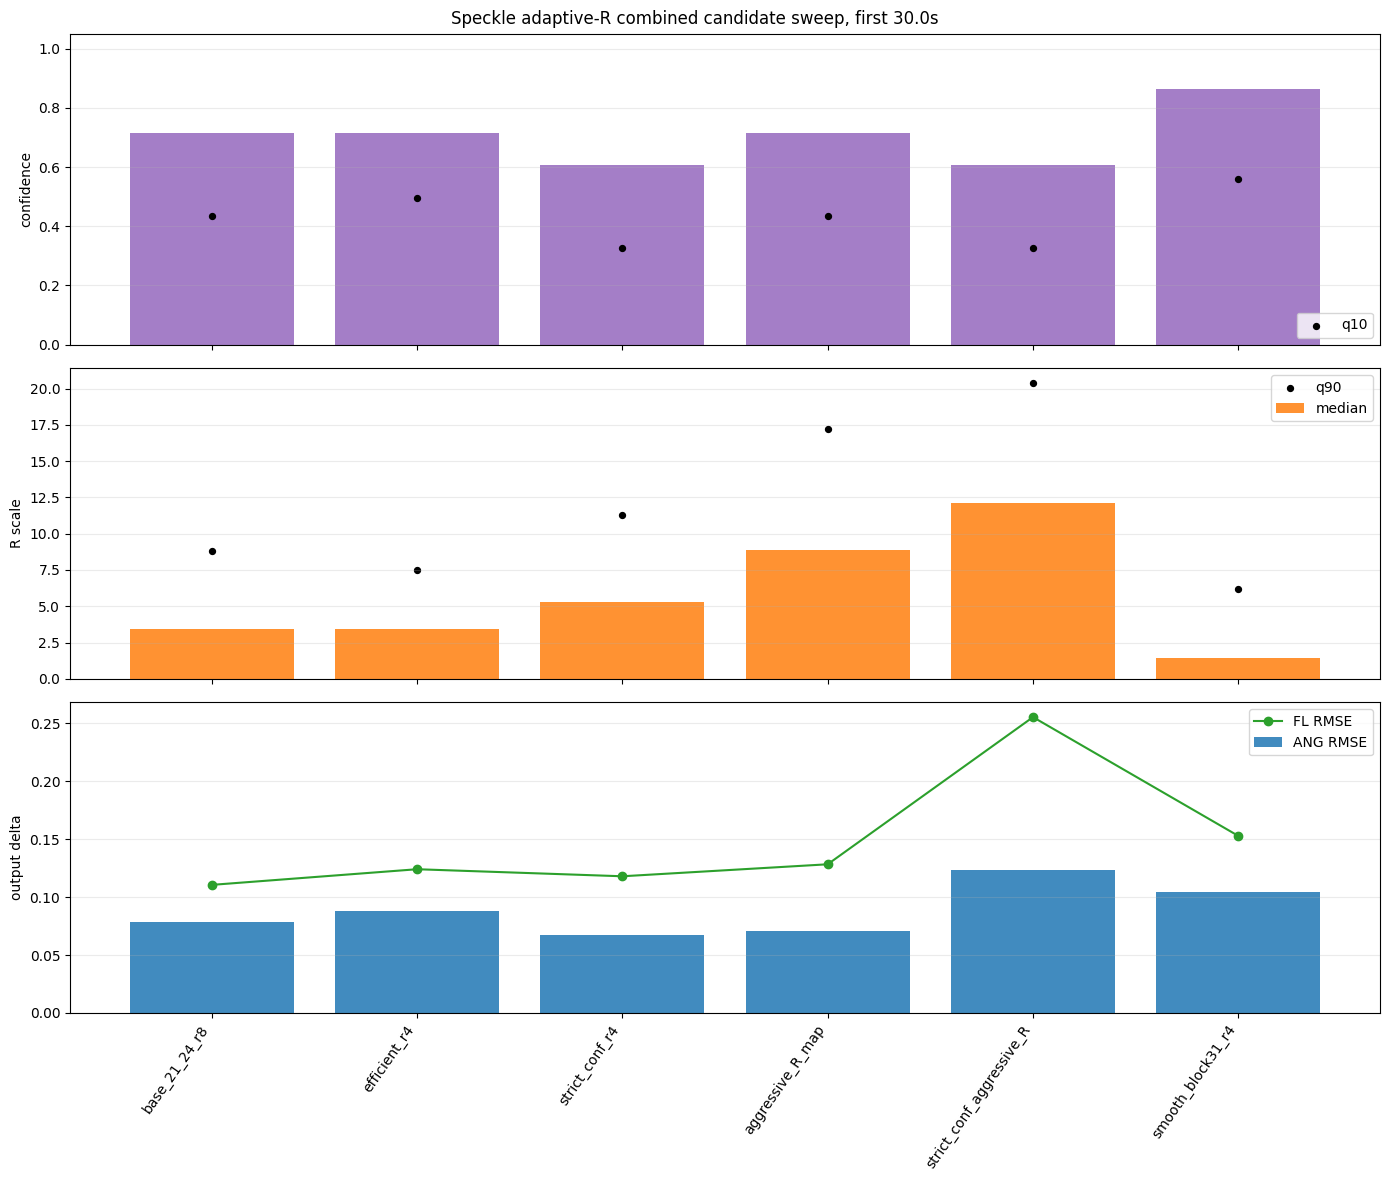

In [8]:
plot_order = summary['name'].tolist()
x = np.arange(len(plot_order))

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
axes[0].bar(x, summary.set_index('name').loc[plot_order, 'confidence_median'], color='tab:purple', alpha=0.85)
axes[0].scatter(x, summary.set_index('name').loc[plot_order, 'confidence_q10'], color='black', s=18, label='q10')
axes[0].set_ylabel('confidence')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')

axes[1].bar(x, summary.set_index('name').loc[plot_order, 'R_scale_median'], color='tab:orange', alpha=0.85, label='median')
axes[1].scatter(x, summary.set_index('name').loc[plot_order, 'R_scale_q90'], color='black', s=18, label='q90')
axes[1].set_ylabel('R scale')
axes[1].legend(loc='upper right')

axes[2].bar(x, summary.set_index('name').loc[plot_order, 'theta_delta_rmse_deg'], color='tab:blue', alpha=0.85, label='ANG RMSE')
axes[2].plot(x, summary.set_index('name').loc[plot_order, 'length_delta_rmse_mm'], color='tab:green', marker='o', lw=1.5, label='FL RMSE')
axes[2].set_ylabel('output delta')
axes[2].legend(loc='upper right')
axes[2].set_xticks(x)
axes[2].set_xticklabels(plot_order, rotation=55, ha='right')
for ax in axes:
    ax.grid(True, axis='y', alpha=0.25)
fig.suptitle(f'Speckle adaptive-R combined candidate sweep, first {time_conf[-1]:.1f}s')
fig.tight_layout()
path = OUT / 'combined_candidate_summary_bars.png'
fig.savefig(path, dpi=170)
path

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook64_speckle_adaptive_R_combined_candidates/combined_candidate_traces.png')

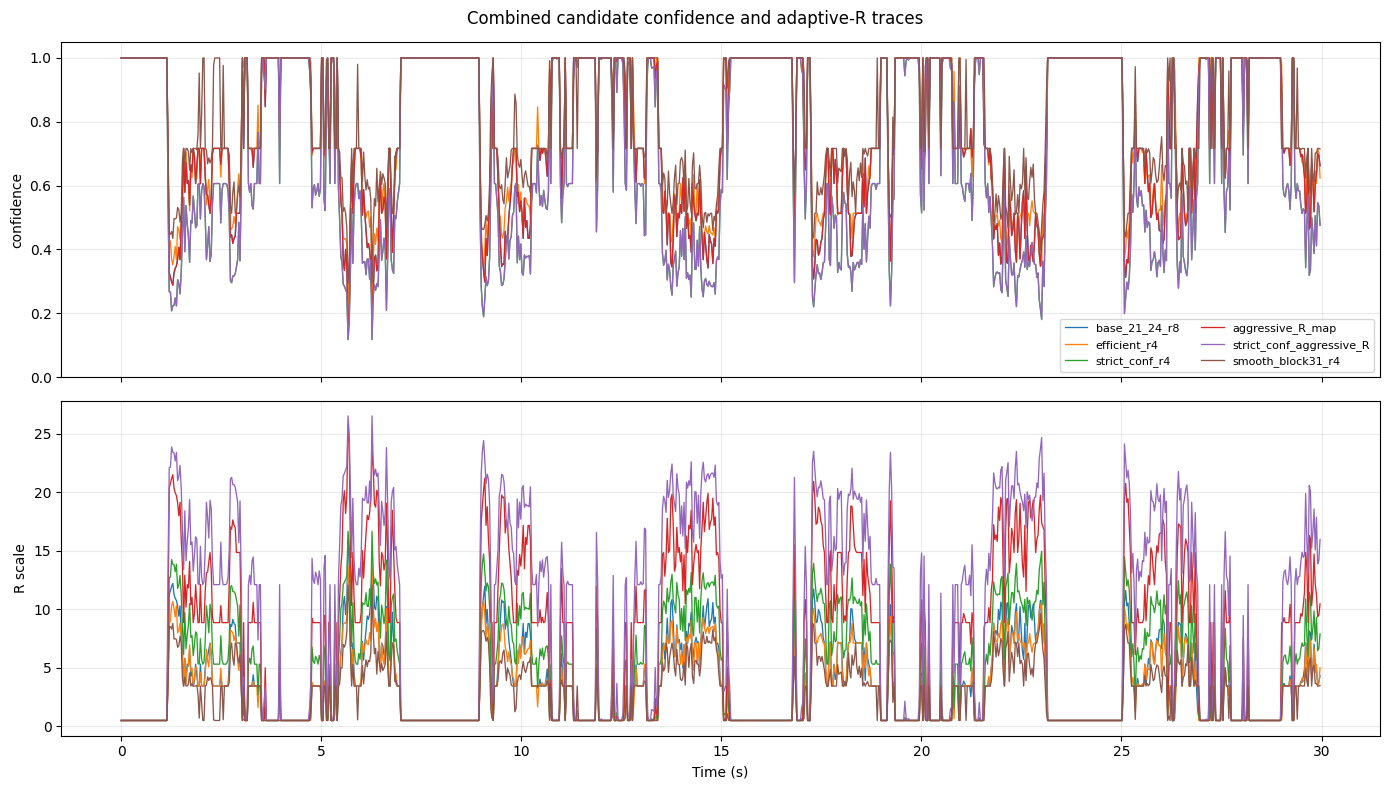

In [9]:
representatives = summary['name'].tolist()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for name in representatives:
    axes[0].plot(time_conf, confidence_results[name]['combined_confidence'], lw=0.95, label=name)
    axes[1].plot(time_conf, confidence_results[name]['R_scale'], lw=0.95, label=name)
axes[0].set_ylabel('confidence')
axes[0].set_ylim(0, 1.05)
axes[1].set_ylabel('R scale')
axes[1].set_xlabel('Time (s)')
for ax in axes:
    ax.grid(True, alpha=0.25)
axes[0].legend(ncol=2, fontsize=8)
fig.suptitle('Combined candidate confidence and adaptive-R traces')
fig.tight_layout()
path = OUT / 'combined_candidate_traces.png'
fig.savefig(path, dpi=170)
path

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook64_speckle_adaptive_R_combined_candidates/combined_candidate_Rscale_vs_angle_delta_scatter.png')

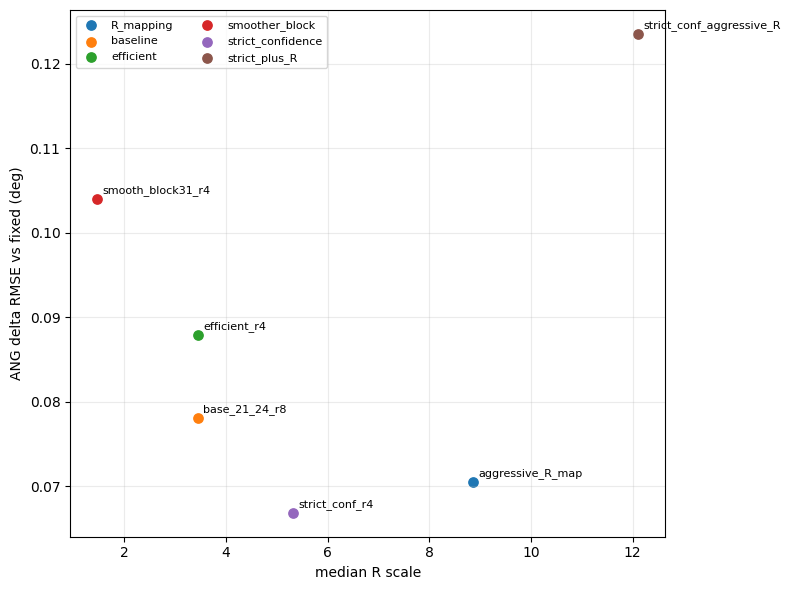

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for group, group_df in summary.groupby('group'):
    ax.scatter(group_df['R_scale_median'], group_df['theta_delta_rmse_deg'], label=group, s=45)
for _, row in summary.iterrows():
    if True:
        ax.annotate(row['name'], (row['R_scale_median'], row['theta_delta_rmse_deg']), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('median R scale')
ax.set_ylabel('ANG delta RMSE vs fixed (deg)')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
path = OUT / 'combined_candidate_Rscale_vs_angle_delta_scatter.png'
fig.savefig(path, dpi=170)
path

## 8. First-Pass Interpretation

This cell writes a compact text summary from the combined candidates, with emphasis on choosing the next recipe to carry into a full-video run.


In [11]:
base_row = summary.set_index('name').loc['base_21_24_r8']
interesting = summary.copy()
interesting['delta_conf_q10_vs_base'] = interesting['confidence_q10'] - float(base_row['confidence_q10'])
interesting['delta_conf_median_vs_base'] = interesting['confidence_median'] - float(base_row['confidence_median'])
interesting['delta_R_median_vs_base'] = interesting['R_scale_median'] - float(base_row['R_scale_median'])
interesting['delta_R_q90_vs_base'] = interesting['R_scale_q90'] - float(base_row['R_scale_q90'])
interesting['delta_theta_rmse_vs_base'] = interesting['theta_delta_rmse_deg'] - float(base_row['theta_delta_rmse_deg'])
interesting['delta_length_rmse_vs_base'] = interesting['length_delta_rmse_mm'] - float(base_row['length_delta_rmse_mm'])

rank = interesting[interesting['name'] != 'base_21_24_r8'].copy()
# Prefer candidates that reduce output delta, keep a meaningful high-R tail, and avoid collapsing median R too low.
rank['candidate_score'] = (
    -rank['theta_delta_rmse_deg'].rank(method='min')
    -0.5 * rank['length_delta_rmse_mm'].rank(method='min')
    +0.5 * rank['R_scale_q90'].rank(method='min')
    -0.25 * (rank['R_scale_median'] < 1.0).astype(float)
)
rank = rank.sort_values('candidate_score', ascending=False)

text_lines = []
text_lines.append(f"Base median confidence: {base_row['confidence_median']:.3f}")
text_lines.append(f"Base q10 confidence: {base_row['confidence_q10']:.3f}")
text_lines.append(f"Base median R_scale: {base_row['R_scale_median']:.3f}")
text_lines.append(f"Base R_scale q90: {base_row['R_scale_q90']:.3f}")
text_lines.append(f"Base ANG delta RMSE: {base_row['theta_delta_rmse_deg']:.4f} deg")
text_lines.append(f"Base FL delta RMSE: {base_row['length_delta_rmse_mm']:.4f} mm")
text_lines.append('')
text_lines.append('Combined candidates sorted by ANG delta RMSE:')
for _, row in interesting.sort_values('theta_delta_rmse_deg').iterrows():
    text_lines.append(
        f"- {row['name']}: ANG {row['theta_delta_rmse_deg']:.4f} deg, "
        f"FL {row['length_delta_rmse_mm']:.4f} mm, "
        f"conf q10 {row['confidence_q10']:.3f}, R median/q90 {row['R_scale_median']:.2f}/{row['R_scale_q90']:.2f}"
    )
text_lines.append('')
text_lines.append('Most promising next full-video candidates:')
for _, row in rank.head(3).iterrows():
    text_lines.append(
        f"- {row['name']}: {row['note']} "
        f"(ANG {row['theta_delta_rmse_deg']:.4f}, FL {row['length_delta_rmse_mm']:.4f}, "
        f"R median/q90 {row['R_scale_median']:.2f}/{row['R_scale_q90']:.2f})"
    )

summary_txt = OUT / 'combined_candidate_interpretation.txt'
summary_txt.write_text('\n'.join(text_lines), encoding='utf-8')
print('\n'.join(text_lines))
print('Saved:', summary_txt)

Base median confidence: 0.717
Base q10 confidence: 0.435
Base median R_scale: 3.443
Base R_scale q90: 8.790
Base ANG delta RMSE: 0.0781 deg
Base FL delta RMSE: 0.1106 mm

Combined candidates sorted by ANG delta RMSE:
- strict_conf_r4: ANG 0.0669 deg, FL 0.1180 mm, conf q10 0.326, R median/q90 5.31/11.29
- aggressive_R_map: ANG 0.0705 deg, FL 0.1283 mm, conf q10 0.435, R median/q90 8.86/17.18
- base_21_24_r8: ANG 0.0781 deg, FL 0.1106 mm, conf q10 0.435, R median/q90 3.44/8.79
- efficient_r4: ANG 0.0880 deg, FL 0.1241 mm, conf q10 0.495, R median/q90 3.44/7.51
- smooth_block31_r4: ANG 0.1041 deg, FL 0.1528 mm, conf q10 0.559, R median/q90 1.47/6.20
- strict_conf_aggressive_R: ANG 0.1235 deg, FL 0.2554 mm, conf q10 0.326, R median/q90 12.11/20.38

Most promising next full-video candidates:
- strict_conf_r4: stricter ZNCC, forward-backward, and motion-coherence penalties (ANG 0.0669, FL 0.1180, R median/q90 5.31/11.29)
- aggressive_R_map: same confidence as base, but stronger R response w